In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

from specula.mmlib.analyse_data import get_sim_data
from specula.mmlib.utils import show_psf, get_reference_psf, get_pupil_mask
from specula.lib.radial_profile import compute_radial_profile

from specula.lib.calc_psf import calc_psf

2026-06-18 12:09:45,330 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-06-18 12:09:45,461 [INFO]: [specula]: Default device is GPU number 0
2026-06-18 12:09:46,622 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-06-18 12:09:46,623 [INFO]: [specula]: Default device is GPU number 0


In [2]:
# def show_gain_matrix(df, cmap='inferno', figsize=(8, 6), vmin=None, vmax=None):

#     # Use only gain1, gain2 and sr values; ignore freq
#     gain1_values = np.unique(df['gain1'])
#     gain2_values = np.unique(df['gain2'])

#     gain1_index = {g: i for i, g in enumerate(gain1_values)}
#     gain2_index = {g: i for i, g in enumerate(gain2_values)}

#     sr_matrix = np.full((gain1_values.size, gain2_values.size), np.nan, dtype=float)
#     for _, row in df.iterrows():
#         sr_matrix[gain1_index[row['gain1']], gain2_index[row['gain2']]] = row['sr']

#     fig, ax = plt.subplots(figsize=figsize)
#     im = ax.imshow(sr_matrix, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
#     cbar = fig.colorbar(im, ax=ax)
#     cbar.set_label('sr')

#     ax.set_xticks(np.arange(gain2_values.size))
#     ax.set_xticklabels([f'{g:1.3f}' for g in gain2_values], rotation=45, ha='right')
#     ax.set_yticks(np.arange(gain1_values.size))
#     ax.set_yticklabels([f'{g:1.3f}' for g in gain1_values])

#     ax.set_xlabel('gain2')
#     ax.set_ylabel('gain1')
#     ax.set_title('SR matrix over gain1 / gain2')

#     threshold = (np.nanmin(sr_matrix) + np.nanmax(sr_matrix)) / 2.0
#     for i in range(gain1_values.size):
#         for j in range(gain2_values.size):
#             value = sr_matrix[i, j]
#             if np.isfinite(value):
#                 text_color = 'white' if value < threshold else 'black'
#                 ax.text(j, i, f'{value:1.3f}', ha='center', va='center', color=text_color, fontsize=9)

#     plt.tight_layout()
#     return fig, ax

# # Example usage
# show_gain_matrix(df_f1)
# show_gain_matrix(df_f2)
# show_gain_matrix(df_f4)


In [3]:

# dfd = pd.read_csv('/raid1/mmenessini/results/Cascading/e2e_csv/ristretto_faint_dCAO.csv')
# dfd

In [4]:
def calc_coro_psf(phase,amp,use_average_field:bool=True,norm=None,oversampling:int=4):    
    # L = np.max(phase.shape)
    # phase -= np.mean(phase)
    # pad_amp = np.pad(amp, int((oversampling-1)/2*L), mode='constant', constant_values=0.0)
    # pad_phase = np.pad(phase, int((oversampling-1)/2*L), mode='constant', constant_values=0.0)
    electric_field = amp * np.exp(1j * phase, dtype=complex)
    pupil_mask = amp > 0
    if use_average_field is True: # average field removal
        avg_electric_field = np.sum(electric_field * pupil_mask) / np.sum(pupil_mask)
        electric_field_corrected = electric_field - avg_electric_field * pupil_mask
    else: # perfect coronagraph formula (Cavarroc et al. 2006, Eq. 1)
        mean_phase = np.sum(phase * pupil_mask) / np.sum(pupil_mask)
        var_phase = np.sum(((phase - mean_phase) ** 2) * pupil_mask) / np.sum(pupil_mask)
        ec = np.exp(-var_phase)
        coherent_core = np.sqrt(ec) * np.exp(1j * mean_phase, dtype=complex) * amp
        electric_field_corrected = electric_field - coherent_core * pupil_mask

    # focal_field = np.fft.fft2(electric_field_corrected)
    # focal_field = np.fft.fftshift(focal_field)
    # coronagraph_psf = np.abs(focal_field*np.conj(focal_field))
    # if norm is None:
    #     norm = np.sum(coronagraph_psf)
    # coronagraph_psf /= norm
    coronagraph_psf = calc_psf(np.angle(electric_field_corrected),np.abs(electric_field_corrected), imwidth=int(amp.shape[1]*oversampling), normalize=True,
                                            xp=np, complex_dtype=complex)
    return coronagraph_psf

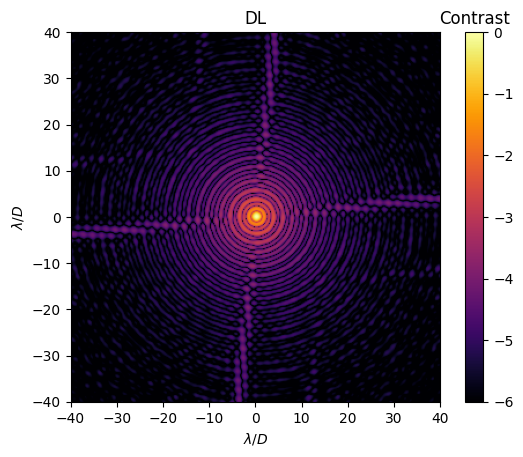

In [5]:
cascading_dir = '/raid1/mmenessini/results/Cascading'
xao_dir = '/raid1/mmenessini/results/XAO'
ekarus_dir = '/raid1/mmenessini/results/EKARUS'
calib_dir = '/raid1/mmenessini/calibration/XAO'

oversampling = 4
pupil_tag = 'vlt_pupil_160pixels'
psf_dl = get_reference_psf(root_dir=calib_dir,pupil_tag=pupil_tag,nd=oversampling)
# pupil_tag = 'copernico_pupil_120pixels'
# psf_dl = get_reference_psf(root_dir='/raid1/mmenessini/calibration/EKARUS',pupil_tag=pupil_tag,nd=oversampling)

show_psf(psf_dl, title='DL', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-6, maxVal=np.max(psf_dl))

Using data directory: /raid1/mmenessini/results/Cascading/20260617_125141
key: coro_psf1_int type: <class 'numpy.ndarray'>
key: sr1 type: <class 'numpy.ndarray'>
key: dm1_res type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: sr2 type: <class 'numpy.ndarray'>
key: coro_psf2_int type: <class 'numpy.ndarray'>
key: coro_psf2 type: <class 'numpy.ndarray'>
key: coro_psf1 type: <class 'numpy.ndarray'>
key: dm2_res type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260525_170654
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: atmo_phase type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>


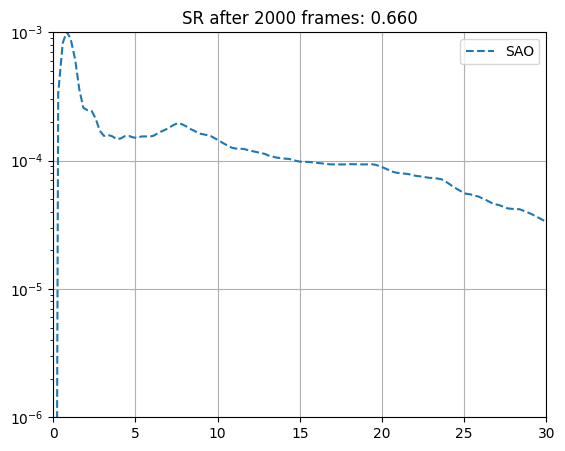

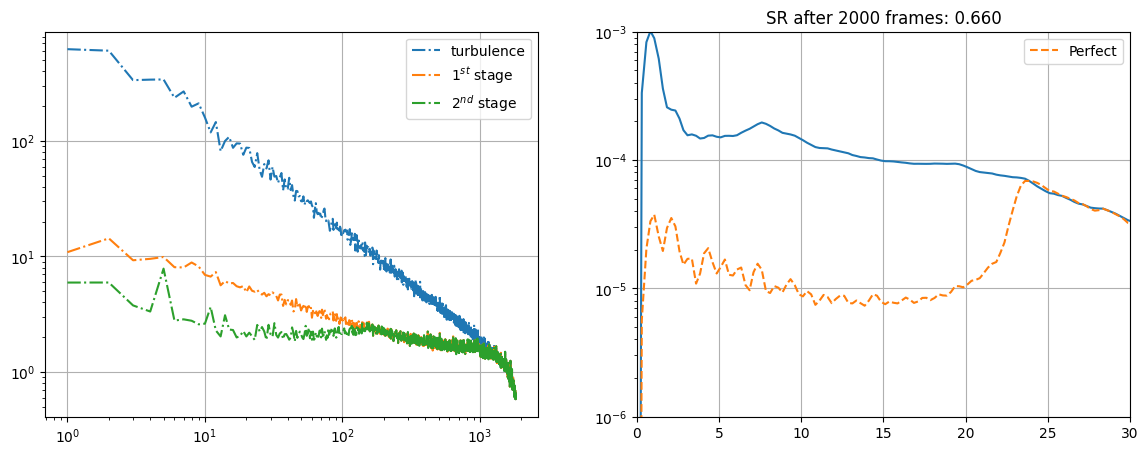

In [6]:
data = get_sim_data(root_dir=cascading_dir)#,tn='20260527_122941') #,tn='20260527_122941 ,tn='20260617_122138'

try:
    amps = data['atmo_phase'][:,0,:,:]
    phases = data['atmo_phase'][:,1,:,:]
    mask = data['atmo_phase'][0,0,:,:]==0
    plt.figure()
    plt.imshow(np.ma.masked_array(phases[1000]-np.mean(phases[1000]),mask=mask),origin='lower',cmap='RdBu',vmin=-500,vmax=500)
    plt.colorbar()
except KeyError:
    pass
try:
    init = int(1.0/0.0005)    
    coro_profile = data['coro_psf2'][0]
    sr = data['sr2']
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,2)
    plt.semilogy(coro_profile[0],coro_profile[1]*oversampling**2,'--',label='SAO')
    plt.ylim([1e-6,1e-3])
    plt.xlim([0,30])
    plt.title(f'SR after {init} frames: {np.mean(sr[init:]):1.3f}')
    plt.legend()
    plt.grid()
    mode_rms = lambda vec: np.sqrt(np.mean(vec**2,axis=0))
    atmo_rms = mode_rms(data['atmo_res'][init:])
    dm1_rms = mode_rms(data['dm_res'][init:])
    x = np.arange(len(atmo_rms))+1
    plt.subplot(1,2,1)
    plt.loglog(x,atmo_rms,'-.',label='turbulence')
    plt.loglog(x,dm1_rms,'-.',label=r'AO correction')
    try:
        dm2_rms = mode_rms(data['dm2_res'][init:])
        plt.loglog(x,dm2_rms,'-.',label=r'$2^{nd}$ stage')
    except KeyError:
        pass
    plt.legend()
    plt.grid()
except KeyError:
    pass

try:
    coro_std = data['coro_psf_std_profile'][0]
    coro_int = data['coro_psf_int_profile'][0]
    plt.figure()
    line, = plt.semilogy(coro_int[0], coro_int[1]*oversampling**2, '--', label='INT')
    plt.fill_between(
        coro_int[0],
        np.maximum(coro_int[1]*oversampling**2 - coro_std[1]*oversampling**2, 1e-20),
        coro_int[1]*oversampling**2 + coro_std[1]*oversampling**2,
        color=line.get_color(),
        alpha=0.25,
        linewidth=0
    )
    plt.ylim([1e-7,1e-3])
    plt.xlim([0,30])
    plt.legend()
    plt.grid()
except KeyError:
    init = int(0.5/0.00025)    
    try:
        sr = data['sr2']
    except KeyError:
        sr = data['sr1']
    ref_data = get_sim_data(root_dir=xao_dir,tn='20260525_170654')
    coro_std = ref_data['coro_psf_std_profile'][0]
    coro_int = ref_data['coro_psf_int_profile'][0]
    try:
        coro_profile = data['coro_psf2'][0]
    except KeyError:
        coro_profile = data['coro_psf1'][0]
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,2)
    plt.semilogy(coro_profile[0], coro_profile[1]*oversampling**2)
    line, = plt.semilogy(coro_int[0], coro_std[1]*oversampling**2, '--', label='Perfect')
    # plt.fill_between(
    #     coro_profile[0],
    #     np.maximum((coro_int[1] - coro_std[1])*oversampling**2, 1e-20),
    #     (coro_int[1] + coro_std[1])*oversampling**2,
    #     color=line.get_color(),
    #     alpha=0.25,
    #     linewidth=0
    # )
    plt.ylim([1e-6,1e-3])
    plt.xlim([0,30])
    plt.title(f'SR after {init} frames: {np.mean(sr[init:]):1.3f}')
    plt.legend()
    plt.grid()

    mode_rms = lambda vec: np.sqrt(np.mean(vec**2,axis=0))
    atmo_rms = mode_rms(data['atmo_res'][init:])
    dm1_rms = mode_rms(data['dm1_res'][init:])
    x = np.arange(len(atmo_rms))+1
    plt.subplot(1,2,1)
    plt.loglog(x,atmo_rms,'-.',label='turbulence')
    plt.loglog(x,dm1_rms,'-.',label=r'$1^{st}$ stage')
    try:
        dm2_rms = mode_rms(data['dm2_res'][init:])
        plt.loglog(x,dm2_rms,'-.',label=r'$2^{nd}$ stage')
    except KeyError:
        pass
    plt.legend()
    plt.grid()


Using data directory: /raid1/mmenessini/results/XAO/20260525_170654
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: atmo_phase type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260525_172932
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: atmo_phase type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260525_173231
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: atmo_phase type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260525_173448
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>


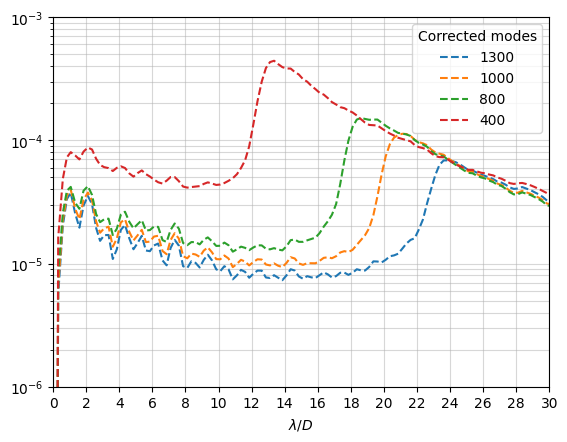

In [7]:
con1300m_750 = get_sim_data(xao_dir,tn='20260525_170654')
con1000m_750 = get_sim_data(xao_dir,tn='20260525_172932')
con800m_750 = get_sim_data(xao_dir,tn='20260525_173231')
con400m_750 = get_sim_data(xao_dir,tn='20260525_173448')

coro_std1300 = con1300m_750['coro_psf_std_profile'][0]
coro_std1000 = con1000m_750['coro_psf_std_profile'][0]
coro_std800 = con800m_750['coro_psf_std_profile'][0]
coro_std400 = con400m_750['coro_psf_std_profile'][0]

plt.figure()
plt.semilogy(coro_std1300[0],coro_std1300[1]*oversampling**2,'--',label='1300')
plt.semilogy(coro_std1000[0],coro_std1000[1]*oversampling**2,'--',label='1000')
plt.semilogy(coro_std800[0],coro_std800[1]*oversampling**2,'--',label='800')
plt.semilogy(coro_std400[0],coro_std400[1]*oversampling**2,'--',label='400')
plt.legend(title='Corrected modes',loc='best')
plt.xlabel(r'$\lambda/D$')
plt.xticks(np.arange(0,32,2))
# plt.ylabel('')
plt.ylim([1e-6,1e-3])
plt.xlim([0,30])
plt.grid(which='both',alpha=0.5)

Using data directory: /raid1/mmenessini/results/XAO/20260606_160556
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260606_161722
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260606_160912
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260606_161037
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260606_161152
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>


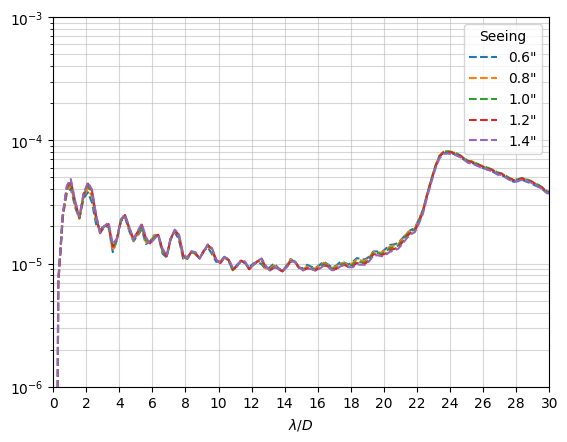

In [8]:
con_s06 = get_sim_data(xao_dir,tn='20260606_160556')
con_s08 = get_sim_data(xao_dir,tn='20260606_161722')
con_s10 = get_sim_data(xao_dir,tn='20260606_160912')
con_s12 = get_sim_data(xao_dir,tn='20260606_161037')
con_s14 = get_sim_data(xao_dir,tn='20260606_161152')

coro_s06 = con_s06['coro_psf_std_profile'][0]
coro_s08 = con_s08['coro_psf_std_profile'][0]
coro_s10 = con_s10['coro_psf_std_profile'][0]
coro_s12 = con_s12['coro_psf_std_profile'][0]
coro_s14 = con_s14['coro_psf_std_profile'][0]

plt.figure()
plt.semilogy(coro_std1300[0],coro_s06[1]*oversampling**2*(1.0/0.6)**(8/6),'--',label='0.6"')
plt.semilogy(coro_std1000[0],coro_s08[1]*oversampling**2*(1.0/0.8)**(8/6),'--',label='0.8"')
plt.semilogy(coro_std800[0],coro_s10[1]*oversampling**2,'--',label='1.0"')
plt.semilogy(coro_std400[0],coro_s12[1]*oversampling**2*(1.0/1.2)**(8/6),'--',label='1.2"')
plt.semilogy(coro_std400[0],coro_s14[1]*oversampling**2*(1.0/1.4)**(8/6),'--',label='1.4"')
plt.legend(title='Seeing',loc='best')
plt.xlabel(r'$\lambda/D$')
plt.xticks(np.arange(0,32,2))
# plt.ylabel('')
plt.ylim([1e-6,1e-3])
plt.xlim([0,30])
plt.grid(which='both',alpha=0.5)

Using data directory: /raid1/mmenessini/results/XAO/20260606_160912
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260606_161850
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260606_162025
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260606_162430
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>


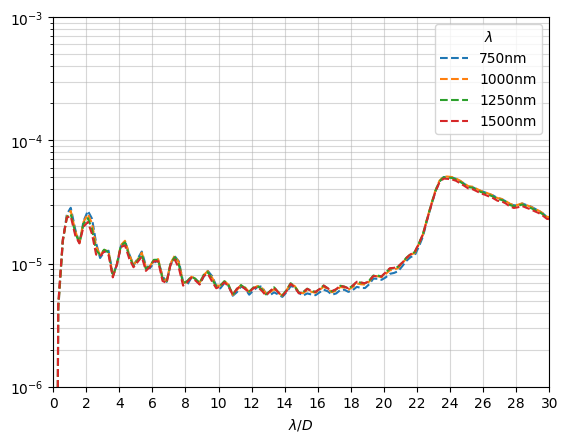

In [9]:

con_750 = get_sim_data(xao_dir,tn='20260606_160912')
con_1000 = get_sim_data(xao_dir,tn='20260606_161850')
con_1250 = get_sim_data(xao_dir,tn='20260606_162025')
con_1500 = get_sim_data(xao_dir,tn='20260606_162430')

coro_750 = con_750['coro_psf_std_profile'][0]
coro_1000 = con_1000['coro_psf_std_profile'][0]
coro_1250 = con_1250['coro_psf_std_profile'][0]
coro_1500 = con_1500['coro_psf_std_profile'][0]

plt.figure()
plt.semilogy(coro_std1300[0],coro_750[1]*oversampling**2*(1000/750)**(-5/3),'--',label='750nm')
plt.semilogy(coro_std1000[0],coro_1000[1]*oversampling**2,'--',label='1000nm')
plt.semilogy(coro_std800[0],coro_1250[1]*oversampling**2*(1000/1250)**(-5/3),'--',label='1250nm')
plt.semilogy(coro_std400[0],coro_1500[1]*oversampling**2*(1000/1500)**(-5/3),'--',label='1500nm')
plt.legend(title=r'$\lambda$',loc='best')
plt.xlabel(r'$\lambda/D$')
plt.xticks(np.arange(0,32,2))
# plt.ylabel('')
plt.ylim([1e-6,1e-3])
plt.xlim([0,30])
plt.grid(which='both',alpha=0.5)

In [10]:
# print(data['opt_gains'].shape)

# x = np.arange(400)+1
# plt.figure()
# for N in np.array([100,400,800,1000,2000]):
#     plt.plot(x,np.mean(data['opt_gains'][:N,:],axis=0))
# plt.grid()
# plt.xscale('log')

In [11]:
from specula.mmlib.compute_rec import rec_noise, rec_ron_cov, rec_phot_cov
from specula.mmlib.utils import get_pupil_mask

616364.94 505629.84 482903.56 473479.88
0.9319957


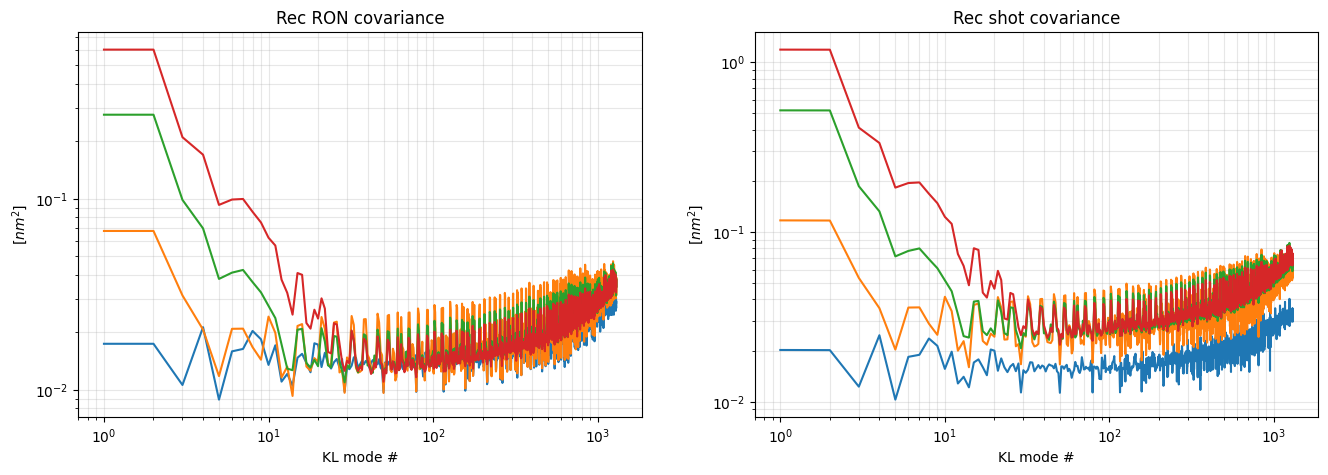

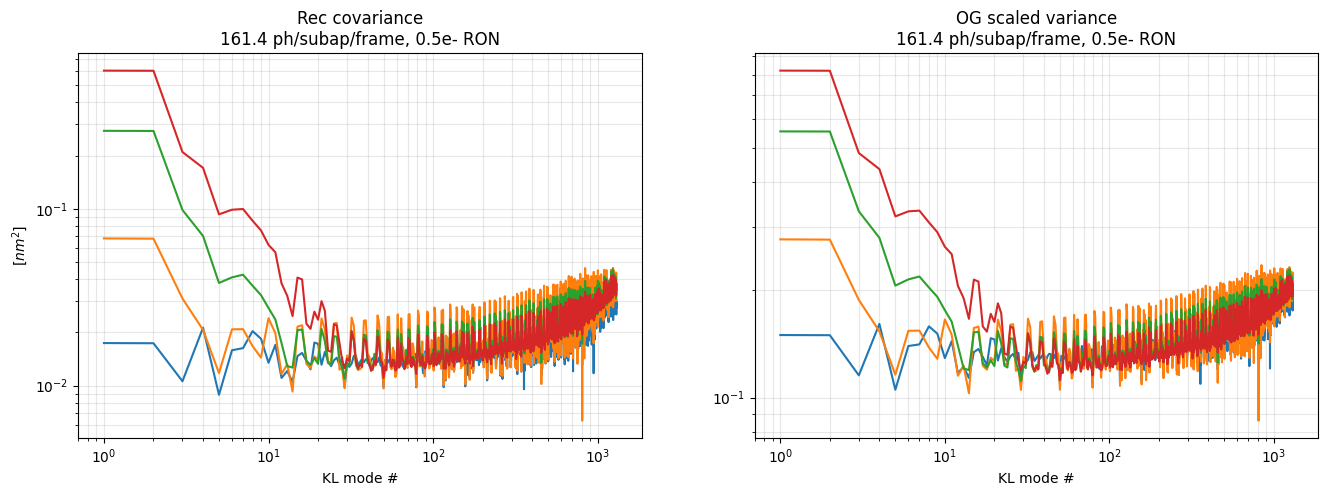

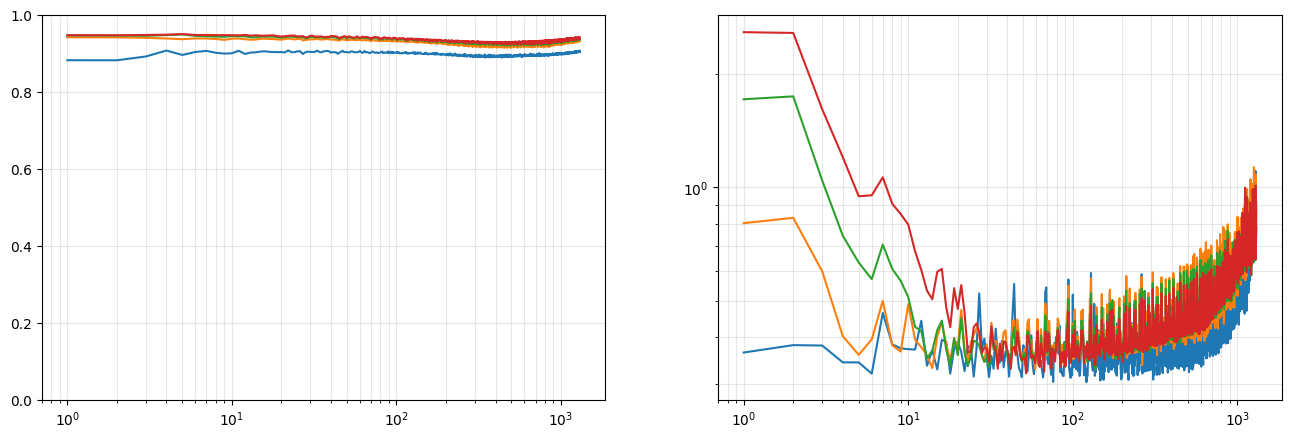

In [12]:
seeing = 0.9
N = 1300

frame09p1 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/frames/pyr1.0_48x48_s{seeing:1.2f}_{N}modes_avg_frame.fits')
frame09p0 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/frames/pyr0.0_48x48_s{seeing:1.2f}_{N}modes_avg_frame.fits')
frame09p2 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/frames/pyr2.0_48x48_s{seeing:1.2f}_{N}modes_avg_frame.fits')
frame09p3 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/frames/pyr3.0_48x48_s{seeing:1.2f}_{N}modes_avg_frame.fits')

pyr48_mask = get_pupil_mask(npix=120,filepath='/raid1/mmenessini/calibration/RISTRETTO/pupils/pyr_pupdata_48x48.fits')

simpc09p0 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/im/pyr0.0_48x48_s{seeing:1.2f}_{N}modes_simpc.fits')
simpc09p1 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/im/pyr1.0_48x48_s{seeing:1.2f}_{N}modes_simpc.fits')
simpc09p2 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/im/pyr2.0_48x48_s{seeing:1.2f}_{N}modes_simpc.fits')
simpc09p3 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/im/pyr3.0_48x48_s{seeing:1.2f}_{N}modes_simpc.fits')

rec0 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/rec/pyr0.0_48x48_{N}modes_rec.fits')
rec1 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/rec/pyr1.0_48x48_{N}modes_rec.fits')
rec2 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/rec/pyr2.0_48x48_{N}modes_rec.fits')
rec3 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/rec/pyr3.0_48x48_{N}modes_rec.fits')

og0 = np.diag(rec0 @ simpc09p0)
og1 = np.diag(rec1 @ simpc09p1)
og2 = np.diag(rec2 @ simpc09p2)
og3 = np.diag(rec3 @ simpc09p3)

sn0 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/slopenulls/pyr0.0_48x48_s{seeing:1.2f}_{N}modes_sn.fits')
sn1 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/slopenulls/pyr1.0_48x48_s{seeing:1.2f}_{N}modes_sn.fits')
sn2 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/slopenulls/pyr2.0_48x48_s{seeing:1.2f}_{N}modes_sn.fits')
sn3 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/slopenulls/pyr3.0_48x48_s{seeing:1.2f}_{N}modes_sn.fits')

alias0 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/aliasing/pyr0.0_48x48_s{seeing:1.2f}_{N}modes_alias.fits')
alias1 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/aliasing/pyr1.0_48x48_s{seeing:1.2f}_{N}modes_alias.fits')
alias2 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/aliasing/pyr2.0_48x48_s{seeing:1.2f}_{N}modes_alias.fits')
alias3 = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/aliasing/pyr3.0_48x48_s{seeing:1.2f}_{N}modes_alias.fits')



RON = 0.5
Nphot = 2.6e+5
cov0_ron = rec_ron_cov(rec=rec0,frame=frame09p0,mask=pyr48_mask,flux=np.sum(frame09p3))
cov1_ron = rec_ron_cov(rec=rec1,frame=frame09p1,mask=pyr48_mask,flux=np.sum(frame09p3))
cov2_ron = rec_ron_cov(rec=rec2,frame=frame09p2,mask=pyr48_mask,flux=np.sum(frame09p3))
cov3_ron = rec_ron_cov(rec=rec3,frame=frame09p3,mask=pyr48_mask,flux=np.sum(frame09p3))

cov0_phot = rec_phot_cov(rec=rec0,frame=frame09p0,mask=pyr48_mask,sn=sn0+3e-2,flux=np.sum(frame09p3))
cov1_phot = rec_phot_cov(rec=rec1,frame=frame09p1,mask=pyr48_mask,sn=sn1+3e-2,flux=np.sum(frame09p3))
cov2_phot = rec_phot_cov(rec=rec2,frame=frame09p2,mask=pyr48_mask,sn=sn2+3e-2,flux=np.sum(frame09p3))
cov3_phot = rec_phot_cov(rec=rec3,frame=frame09p3,mask=pyr48_mask,sn=sn3+3e-2,flux=np.sum(frame09p3))

cov0 = rec_noise(rec=rec0,frame=frame09p0,mask=pyr48_mask,sn=sn0,RON=RON,Nphot=Nphot,flux=np.sum(frame09p3))
cov1 = rec_noise(rec=rec1,frame=frame09p1,mask=pyr48_mask,sn=sn1,RON=RON,Nphot=Nphot,flux=np.sum(frame09p3))
cov2 = rec_noise(rec=rec2,frame=frame09p2,mask=pyr48_mask,sn=sn2,RON=RON,Nphot=Nphot,flux=np.sum(frame09p3))
cov3 = rec_noise(rec=rec3,frame=frame09p3,mask=pyr48_mask,sn=sn3,RON=RON,Nphot=Nphot,flux=np.sum(frame09p3))

x = np.arange(N)+1

plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plt.loglog(x,cov0_ron*RON/Nphot**2)
plt.loglog(x,cov1_ron*RON/Nphot**2)
plt.loglog(x,cov2_ron*RON/Nphot**2)
plt.loglog(x,cov3_ron*RON/Nphot**2)
plt.grid(which='both',alpha=0.3)
plt.xlabel('KL mode #')
plt.ylabel('$[nm^2]$')
plt.title(f'Rec RON covariance')
plt.subplot(1,2,2)
plt.loglog(x,cov0_phot/Nphot)
plt.loglog(x,cov1_phot/Nphot)
plt.loglog(x,cov2_phot/Nphot)
plt.loglog(x,cov3_phot/Nphot)
plt.grid(which='both',alpha=0.3)
plt.xlabel('KL mode #')
plt.ylabel('$[nm^2]$')
plt.title(f'Rec shot covariance')

print(np.sum(np.sqrt(cov0_ron*RON/cov0_phot)),np.sum(np.sqrt(cov1_ron*RON/cov1_phot)),np.sum(np.sqrt(cov2_ron*RON/cov2_phot)),np.sum(np.sqrt(cov3_ron*RON/cov3_phot)))

plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plt.loglog(x,cov0)
plt.loglog(x,cov1)
plt.loglog(x,cov2)
plt.loglog(x,cov3)
plt.grid(which='both',alpha=0.3)
plt.xlabel('KL mode #')
plt.ylabel('$[nm^2]$')
plt.title(f'Rec covariance\n{Nphot/(np.pi/4*(48**2-0.11*48**2)):1.1f} ph/subap/frame, {RON:1.1f}e- RON')
plt.subplot(1,2,2)
plt.loglog(x,np.sqrt(cov0/og0**2))
plt.loglog(x,np.sqrt(cov1/og1**2))
plt.loglog(x,np.sqrt(cov2/og2**2))
plt.loglog(x,np.sqrt(cov3/og3**2))
# ref = cov0/og0**2
# plt.loglog(x,1-cov0/og0**2/(ref+cov0/og0**2))
# plt.loglog(x,1-cov1/og1**2/(ref+cov1/og1**2))
# plt.loglog(x,1-cov2/og2**2/(ref+cov2/og2**2))
# plt.loglog(x,1-cov3/og3**2/(ref+cov3/og3**2))
plt.grid(which='both',alpha=0.3)
plt.xlabel('KL mode #')
plt.title(f'OG scaled variance\n{Nphot/(np.pi/4*(48**2-0.11*48**2)):1.1f} ph/subap/frame, {RON:1.1f}e- RON')

print(np.sqrt(np.sum(cov0[:50]/og0[:50]**2)))

plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plt.plot(x,og0)
plt.plot(x,og1)
plt.plot(x,og2)
plt.plot(x,og3)
plt.ylim([0,1])
plt.xscale('log')
plt.grid(which='both',alpha=0.3)
plt.subplot(1,2,2)
plt.plot(x,alias0/og0)
plt.plot(x,alias1/og1)
plt.plot(x,alias2/og2)
plt.plot(x,alias3/og3)
plt.xscale('log')
plt.yscale('log')
plt.grid(which='both',alpha=0.3)

In [13]:
# import pandas as pd

# df = pd.read_csv('/raid1/mmenessini/results/Cascading/e2e_csv/ristretto_faint_CAO.csv')
# df_close = pd.read_csv('/raid1/mmenessini/results/Cascading/e2e_csv/ristretto_faint_CAO_CLOSE.csv')
# df_dcao = pd.read_csv('/raid1/mmenessini/results/Cascading/e2e_csv/ristretto_faint_dCAO.csv')

# df.iloc[df['sr'].idxmax()]
# # df_close.iloc[df_close['sr'].idxmax()]
# # df_dcao.iloc[df_dcao['sr'].idxmax()]

ValueError: x and y must have same first dimension, but have shapes (1300,) and (150,)

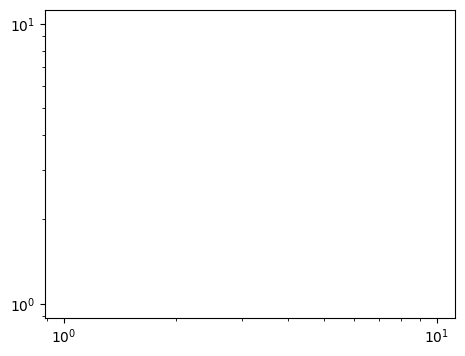

In [14]:
def get_ogs(rMod,seeing,Nmodes,Nsubap:int=48,get_ct=False):
    simpc = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/im/pyr{rMod:1.1f}_{Nsubap}x{Nsubap}_s{seeing:1.2f}_{Nmodes}modes_simpc.fits')
    rec = fits.getdata(f'/raid1/mmenessini/calibration/RISTRETTO/rec/pyr{rMod:1.1f}_{Nsubap}x{Nsubap}_{Nmodes}modes_rec.fits')
    if get_ct: 
        og = rec @ simpc
        return np.diag(rec @ simpc), np.sum(og**2,axis=0)-np.diag(rec @ simpc)**2
    else:
        return np.diag(rec @ simpc)

seeings = np.array([0.9,1.1,1.3])
Nsubap = 48
Nmodes = np.array([150,300,1300])

plt.figure(figsize=(18,4))
for i,seeing in enumerate(seeings):
    plt.subplot(1,3,i+1)
    og0 = get_ogs(rMod=0,seeing=seeing,Nmodes=Nmodes[0],Nsubap=Nsubap)
    og1 = get_ogs(rMod=1,seeing=seeing,Nmodes=Nmodes[0],Nsubap=Nsubap)
    og2 = get_ogs(rMod=2,seeing=seeing,Nmodes=Nmodes[0],Nsubap=Nsubap)
    og3 = get_ogs(rMod=3,seeing=seeing,Nmodes=Nmodes[0],Nsubap=Nsubap)
    plt.loglog(x,og0/og0)
    plt.loglog(x,og1/og0)
    plt.loglog(x,og2/og0)
    plt.loglog(x,og3/og0)
    plt.yscale('linear')
    plt.xlabel('KL mode #')
    plt.ylim([0.9,2.2])
    plt.title(f'Seeing {seeing:1.1f}", {Nmodes[0]} modes corrected')
    plt.grid(which='both',alpha=0.3)

plt.figure(figsize=(18,4))
for i,N in enumerate(Nmodes):
    plt.subplot(1,3,i+1)
    og0 = get_ogs(rMod=0,seeing=seeings[1],Nmodes=N,Nsubap=Nsubap)
    og1 = get_ogs(rMod=1,seeing=seeings[1],Nmodes=N,Nsubap=Nsubap)
    og2 = get_ogs(rMod=2,seeing=seeings[1],Nmodes=N,Nsubap=Nsubap)
    og3 = get_ogs(rMod=3,seeing=seeings[1],Nmodes=N,Nsubap=Nsubap)
    plt.loglog(x,(og0/og0)[:len(x)])
    plt.loglog(x,(og1/og0)[:len(x)])
    plt.loglog(x,(og2/og0)[:len(x)])
    plt.loglog(x,(og3/og0)[:len(x)])
    plt.yscale('linear')
    plt.xlabel('KL mode #')
    plt.ylim([0.9,2.2])
    plt.title(f'Seeing {seeings[1]:1.1f}", {N} modes corrected')
    plt.grid(which='both',alpha=0.3)

Nsubaps = np.array([16,24,48])
plt.figure(figsize=(18,4))
for i,N in enumerate(Nsubaps):
    plt.subplot(1,3,i+1)
    og0 = get_ogs(rMod=0,seeing=seeings[1],Nmodes=Nmodes[0],Nsubap=N)
    og1 = get_ogs(rMod=1,seeing=seeings[1],Nmodes=Nmodes[0],Nsubap=N)
    og2 = get_ogs(rMod=2,seeing=seeings[1],Nmodes=Nmodes[0],Nsubap=N)
    og3 = get_ogs(rMod=3,seeing=seeings[1],Nmodes=Nmodes[0],Nsubap=N)
    plt.loglog(x,(og0/og0)[:len(x)])
    plt.loglog(x,(og1/og0)[:len(x)])
    plt.loglog(x,(og2/og0)[:len(x)])
    plt.loglog(x,(og3/og0)[:len(x)])
    plt.yscale('linear')
    plt.xlabel('KL mode #')
    plt.ylim([0.9,2.2])
    plt.title(f'Seeing {seeings[1]:1.1f}", {Nmodes[0]} modes corrected\n{N}x{N} subaps')
    plt.grid(which='both',alpha=0.3)

N = 300
seeing = 0.9
og0,ct0 = get_ogs(rMod=0,seeing=seeing,Nmodes=N,Nsubap=Nsubap,get_ct=True)
og1,ct1 = get_ogs(rMod=1,seeing=seeing,Nmodes=N,Nsubap=Nsubap,get_ct=True)
og2,ct2 = get_ogs(rMod=2,seeing=seeing,Nmodes=N,Nsubap=Nsubap,get_ct=True)
og3,ct3 = get_ogs(rMod=3,seeing=seeing,Nmodes=N,Nsubap=Nsubap,get_ct=True)

In [ ]:
simpc07 = fits.getdata('/raid1/mmenessini/calibration/RISTRETTO/im/pyr0.0_48x48_s0.70_1300modes_simpc.fits')
simpc09 = fits.getdata('/raid1/mmenessini/calibration/RISTRETTO/im/pyr0.0_48x48_s0.90_1300modes_simpc.fits')
simpc11 = fits.getdata('/raid1/mmenessini/calibration/RISTRETTO/im/pyr0.0_48x48_s1.10_1300modes_simpc.fits')
simpc13 = fits.getdata('/raid1/mmenessini/calibration/RISTRETTO/im/pyr0.0_48x48_s1.30_1300modes_simpc.fits')
simpc15 = fits.getdata('/raid1/mmenessini/calibration/RISTRETTO/im/pyr0.0_48x48_s1.50_1300modes_simpc.fits')
rec = fits.getdata('/raid1/mmenessini/calibration/RISTRETTO/rec/pyr0.0_48x48_1300modes_rec.fits')

og07 = np.diag(rec @ simpc07)
og09 = np.diag(rec @ simpc09)
og11 = np.diag(rec @ simpc11)
og13 = np.diag(rec @ simpc13)
og15 = np.diag(rec @ simpc15)

ogp07 = np.sqrt(np.sum((rec @ simpc07)**2,axis=0)-og07**2)
ogp09 = np.sqrt(np.sum((rec @ simpc09)**2,axis=0)-og09**2)
ogp11 = np.sqrt(np.sum((rec @ simpc11)**2,axis=0)-og11**2)
ogp13 = np.sqrt(np.sum((rec @ simpc13)**2,axis=0)-og13**2)
ogp15 = np.sqrt(np.sum((rec @ simpc15)**2,axis=0)-og15**2)


plt.figure()
plt.plot(og07)
plt.plot(og09)
plt.plot(og11)
plt.plot(og13)
plt.plot(og15)
plt.plot(ogp07,':',c='C0')
plt.plot(ogp09,':',c='C1')
plt.plot(ogp11,':',c='C2')
plt.plot(ogp13,':',c='C3')
plt.plot(ogp15,':',c='C4')
plt.ylim([0,1])
plt.grid()

In [ ]:
# frames = fits.getdata('/raid1/mmenessini/calibration/XAO/frames/pyr0.0_24x24_pc500modes_frames.fits')
# ref_frame = fits.getdata('/raid1/mmenessini/calibration/XAO/frames/pyr0.0_24x24_frame.fits')[0]

# pyr_mask = get_pupil_mask(npix=120,filepath='/raid1/mmenessini/calibration/XAO/pupils/pyr_pupdata_24x24.fits')

# avg_frames = np.mean(frames,axis=0)

# thrp_ref = np.sum(ref_frame[pyr_mask])/np.sum(ref_frame)
# thrp = np.sum(avg_frames[pyr_mask])/np.sum(avg_frames)

# print(np.sum(thrp_ref))

# plt.figure(figsize=(10,4))
# plt.subplot(1,2,1)
# plt.imshow(avg_frames,origin='lower',cmap='RdBu')
# plt.colorbar()
# plt.title(f'Throughput {thrp*1e+2:1.1f}')
# plt.subplot(1,2,2)
# plt.imshow(ref_frame,origin='lower',cmap='RdBu')
# plt.colorbar()
# plt.title(f'Throughput {thrp_ref*1e+2:1.1f}')

In [ ]:
test_psf = calc_psf(phases2[600]*2*np.pi/750, 1-mask, imwidth=int(mask.shape[1]*oversampling), normalize=True, xp=np, complex_dtype=complex)
test_coro_psf = calc_coro_psf(phase=phases[600]*2*np.pi/750,amp=1-mask,use_average_field=True,oversampling=4)

plt.figure(figsize=(10,4))
show_psf(test_psf, cmap='inferno', ext=0.5, oversampling=4, vmin=-6, maxVal=np.max(psf_dl))

In [ ]:

coro_psf_std = np.zeros_like(test_psf)
coro_psf_int = np.zeros_like(test_psf)
N = 6000
for j in range(2000,2000+N):
    coro_psf_int += calc_coro_psf(phase=phases2[j]*2*np.pi/750,amp=1-mask,use_average_field=True)/N

for j in range(2000,2000+N):
    coro_psf_std += (calc_coro_psf(phase=phases2[j]*2*np.pi/750,amp=1-mask,use_average_field=True)-coro_psf_int)**2/N
coro_psf_std = np.sqrt(coro_psf_std)



In [ ]:
plt.figure(figsize=(8,5))
# plt.subplot(1,2,1)
# show_psf(coro_psf_int, cmap='inferno', ext=0.5, oversampling=4, vmin=-4.5, maxVal=np.max(psf_dl))
# plt.subplot(1,2,2)
show_psf(coro_psf_std, cmap='inferno', ext=0.5, oversampling=4, vmin=-4.5, maxVal=np.max(psf_dl))

In [ ]:

# psf_std = np.zeros_like(test_psf)
psf_int = np.zeros_like(test_psf)
N = 6000
for j in range(2000,2000+N):
    psf_int += calc_psf(phases[j]*2*np.pi/750, 1-mask, imwidth=int(mask.shape[1]*oversampling), normalize=True, xp=np, complex_dtype=complex)/N

# for j in range(2000,2000+N):
#     psf_std += (calc_psf(phases[j]*2*np.pi/750, 1-mask, imwidth=int(mask.shape[1]*oversampling), normalize=True, xp=np, complex_dtype=complex)-psf_int)**2/N
# psf_std = np.sqrt(psf_std)

plt.figure(figsize=(8,5))
show_psf(psf_int, cmap='inferno', ext=0.5, oversampling=4, vmin=-6, maxVal=np.max(psf_dl))

In [ ]:
# psf_std = np.zeros_like(test_psf)
psf2_int = np.zeros_like(test_psf)
N = 6000
for j in range(2000,2000+N):
    psf2_int += calc_psf(phases2[j]*2*np.pi/1450, 1-mask, imwidth=int(mask.shape[1]*oversampling), normalize=True, xp=np, complex_dtype=complex)/N

In [ ]:

plt.figure(figsize=(8,5))
show_psf(psf_int, cmap='Blues_r', ext=0.5, oversampling=4, vmin=-5, maxVal=np.max(psf_dl))
plt.figure(figsize=(8,5))
show_psf(psf2_int, cmap='Reds_r', ext=0.5, oversampling=4, vmin=-5, maxVal=np.max(psf_dl))

In [ ]:

ref_data = get_sim_data(root_dir=ekarus_dir,tn='20260601_174911')

In [ ]:
plt.figure()
# plt.semilogy(data['coro_psf'][0][0],data['coro_psf'][0][1]*oversampling**2/(1450/750)**2)
plt.semilogy(data['coro_psf2'][0][0],data['coro_psf2'][0][1]*oversampling**2)
plt.semilogy(ref_data['coro_psf_std_profile'][0][0],ref_data['coro_psf_std_profile'][0][1]*oversampling**2,'--')
plt.ylim([1e-6,1e-2])
plt.xlim([0,30])
plt.grid()

In [ ]:
rad_coro_psf, dist = compute_radial_profile(coro_psf_std)
data = get_sim_data(root_dir=cascading_dir,tn='20260527_122941')
ref_data = get_sim_data(root_dir=xao_dir,tn='20260525_170654')
coro_std = ref_data['coro_psf_std_profile'][0]
coro = data['coro_psf1'][0]

plt.figure()    
plt.semilogy(dist/oversampling,rad_coro_psf,'--',label='SAO')
plt.semilogy(coro[0],coro[1]*oversampling**2,'--')
# plt.semilogy(coro_std[0],coro_std[1]*oversampling**2,':',c='k',label='Perfect')
plt.ylim([1e-6,1e-3])
plt.xlim([0,30])
plt.title('Coronagraphic PSF radial profile') #f'SR after {init} frames: {np.mean(sr[init:]):1.3f}')
plt.ylabel(r'1-$\sigma$ contrast')
plt.xlabel(r'$\lambda/D$')
# plt.legend()
plt.grid()

In [ ]:
tn1kHz = '20260520_102745'
tn2kHz = '20260520_110242'
tn4kHz = '20260520_115326'
tnMod1 = '20260520_120617'
tnMod0 = '20260520_123548'

# Cascading
tnSAO = '20260521_170926' # cascading_iirfilter_1300modes, g = 0.15
tnCAO = '20260521_172032' # int g=0.4, iirfilter_300modes g = 0.2

In [ ]:
dataSAO = get_sim_data(root_dir=cascading_dir,tn=tnSAO)
dataCAO = get_sim_data(root_dir=cascading_dir,tn=tnCAO)

sr = dataSAO['sr2']
srCAO = dataCAO['sr2']

plt.figure()
plt.plot(sr)
plt.plot(srCAO)
plt.grid()

In [ ]:
data1kHz = get_sim_data(root_dir=xao_dir,tn=tn1kHz)
data2kHz = get_sim_data(root_dir=xao_dir,tn=tn2kHz)
data4kHz = get_sim_data(root_dir=xao_dir,tn=tn4kHz)
dataMod1 = get_sim_data(root_dir=xao_dir,tn=tnMod1)
dataMod0 = get_sim_data(root_dir=xao_dir,tn=tnMod0)

sr1k = data1kHz['sr']
sr2k = data2kHz['sr']
sr4k = data4kHz['sr']
sr1 = dataMod1['sr']
sr0 = dataMod0['sr']

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(sr4k)
plt.plot(sr2k)
plt.plot(sr1k)
plt.grid()
plt.subplot(1,2,2)
plt.plot(sr4k)
plt.plot(sr1)
plt.plot(sr0)
plt.grid()

In [ ]:
dt = 0.00025
init = int(0.5/dt)

In [ ]:
coro_psf1kHz = data1kHz['coro_psf']
opt_coro_psf = data1kHz['coro_opt_psf']

coro_psf1kHz_std = np.sqrt(np.mean(coro_psf1kHz[init:]**2,axis=0))
opt_coro_psf_std = np.std(opt_coro_psf,axis=0) #np.sqrt(np.mean(opt_coro_psf[init:]**2,axis=0))

In [ ]:
coro_psf = dataSAO['coro_psf2']
coro_psf_std = np.mean(coro_psf[init:],axis=0) #[init:]**2
plt.figure()
show_psf(coro_psf_std, title='Coro 1 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))

In [ ]:
coro_psf1 = dataCAO['coro_psf1']
coro_psf1_std = np.mean(coro_psf1[init:],axis=0) #[init:]**2
coro_psf2 = dataCAO['coro_psf2']
coro_psf2_std = np.mean(coro_psf2[init:],axis=0) #[init:]**2
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
show_psf(coro_psf1_std, title='Coro 1 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,2,2)
show_psf(coro_psf2_std, title='Coro 1 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))

In [ ]:
coro_psf2kHz = data2kHz['coro_psf']
coro_psf2kHz_std = np.sqrt(np.mean(coro_psf2kHz[init:]**2,axis=0))

coro_psf4kHz = data4kHz['coro_psf']
coro_psf4kHz_std = np.sqrt(np.mean(coro_psf4kHz[init:]**2,axis=0))

In [ ]:
coro_psfmod1 = dataMod1['coro_psf']
coro_psfmod1_std = np.sqrt(np.mean(coro_psfmod1[init:]**2,axis=0))

coro_psfmod0 = dataMod0['coro_psf']
coro_psfmod0_std = np.sqrt(np.mean(coro_psfmod0[init:]**2,axis=0))

In [ ]:
plt.figure(figsize=(20,4))
plt.subplot(1,4,1)
show_psf(coro_psf1kHz_std, title='Coro 1 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,2)
show_psf(coro_psf2kHz_std, title='Coro 2 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,3)
show_psf(coro_psf4kHz_std, title='Coro 4 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,4)
show_psf(opt_coro_psf_std, title='Coro opt', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))

In [ ]:
plt.figure(figsize=(20,4))
plt.subplot(1,4,1)
show_psf(coro_psf4kHz_std, title=r'3 $\lambda/D$', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,2)
show_psf(coro_psfmod1_std, title=r'1 $\lambda/D$', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,3)
show_psf(coro_psfmod0_std, title=r'0 $\lambda/D$', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,4)
show_psf(opt_coro_psf_std, title='Coro opt', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))

In [ ]:
# rad_psf_dl, dist = compute_radial_profile(psf_dl)
rad_psf1kHz_coro, dist = compute_radial_profile(coro_psf1kHz_std)
rad_psf2kHz_coro, dist = compute_radial_profile(coro_psf2kHz_std)
rad_psf4kHz_coro, dist = compute_radial_profile(coro_psf4kHz_std)
rad_psfmod1_coro, dist = compute_radial_profile(coro_psfmod1_std)
rad_psfmod0_coro, dist = compute_radial_profile(coro_psfmod0_std)
rad_psf_opt_coro, dist = compute_radial_profile(opt_coro_psf_std)
# rad_psf2kHz_opt_coro, dist = compute_radial_profile(opt_coro_psf2kHz_std)

In [ ]:

plt.figure(figsize=(8,5))
plt.plot(dist/oversampling, rad_psf1kHz_coro/np.max(psf_dl), '--', label=r'AO 1 kHz')
plt.plot(dist/oversampling, rad_psf2kHz_coro/np.max(psf_dl), '-.', label=r'AO 2 kHz')
plt.plot(dist/oversampling, rad_psf4kHz_coro/np.max(psf_dl), '--+', label=r'AO 4 kHz')
plt.plot(dist/oversampling, rad_psfmod1_coro/np.max(psf_dl), '--+', label=r'AO 4 kHz')
# plt.plot(dist/oversampling, rad_psfmod0_coro/np.max(psf_dl), '--+', label=r'AO 4 kHz')
plt.plot(dist/oversampling, rad_psf_opt_coro/np.max(psf_dl), ':', c='k', label=r'Perfect correction')
plt.legend()
plt.yscale('log')
plt.xlim([0,26])
plt.ylim([1e-6,1e-2])
plt.grid()
plt.title('Perfect coronagraph PSF radial profile')
plt.xlabel(r'$\lambda/D$')